# **🔧 0. Setup**

In [1]:
#define all imprts necessary for the program
!pip -q install torchaudio --upgrade

import torch, torchaudio, matplotlib.pyplot as plt
from torchaudio.utils import download_asset
from torchaudio.transforms import Spectrogram, MelSpectrogram, AmplitudeToDB


# **1. Load a demo clip & basic attributes**

In [2]:
#find the audio shape and calculate duration
wav_path = download_asset("tutorial-assets/steam-train-whistle-daniel_simon.wav")  # ≈1 s clip
wave, sr = torchaudio.load(wav_path)            # wave ⟶ Tensor [chn, samples]

print(f"Shape  : {wave.shape}")                 # (channels, samples)
print(f"Sample-rate: {sr} Hz")
duration = wave.shape[1]/sr
print(f"Duration: {duration:.2f} s")


/tmp/ipython-input-651006787.py:2: UserWarning: torchaudio.utils.download.download_asset has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  wav_path = download_asset("tutorial-assets/steam-train-whistle-daniel_simon.wav")  # ≈1 s clip
100%|██████████| 427k/427k [00:00<00:00, 7.41MB/s]
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnin

Shape  : torch.Size([2, 109368])
Sample-rate: 44100 Hz
Duration: 2.48 s


In [3]:
#playback audio
from IPython import display as disp
disp.Audio(wave, rate=sr)

# **📊 2. Plot the waveform (time domain)**

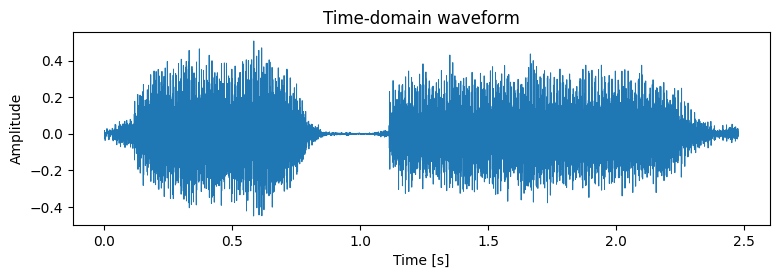

In [ ]:
#Display the waveform
samples = wave[0]                      # first-channel only
times   = torch.arange(samples.size(0))/sr

plt.figure(figsize=(9,2.5))
plt.plot(times, samples, linewidth=0.7)
plt.title("Time-domain waveform")
plt.xlabel("Time [s]"); plt.ylabel("Amplitude")
plt.show()

# **🔎 3. Frequency spectrum (FFT magnitude)**

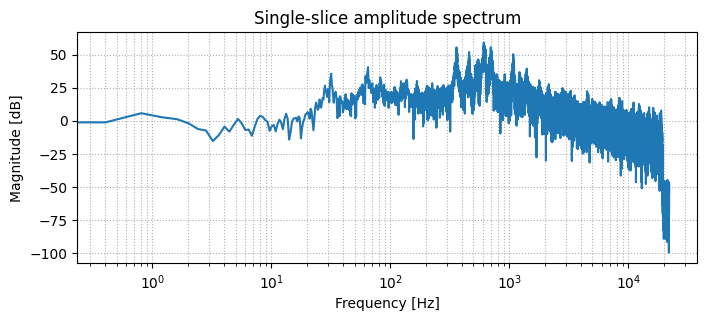

Dominant component ≈ 610.5 Hz


In [ ]:
#@title FFT & log-magnitude plot
import torch.fft as fft

win = torch.hann_window(len(samples))
spec = fft.rfft(samples*win)                     # real-FFT
mag  = torch.abs(spec)
freq = torch.linspace(0, sr/2, mag.numel())

plt.figure(figsize=(8,3))
plt.semilogx(freq, 20*torch.log10(mag+1e-8))
plt.title("Single-slice amplitude spectrum")
plt.xlabel("Frequency [Hz]"); plt.ylabel("Magnitude [dB]")
plt.grid(True, which="both", ls=":")
plt.show()

peak_f = freq[mag.argmax()].item()
print(f"Dominant component ≈ {peak_f:.1f} Hz")


# **4. Spectrogram (STFT → dB)**

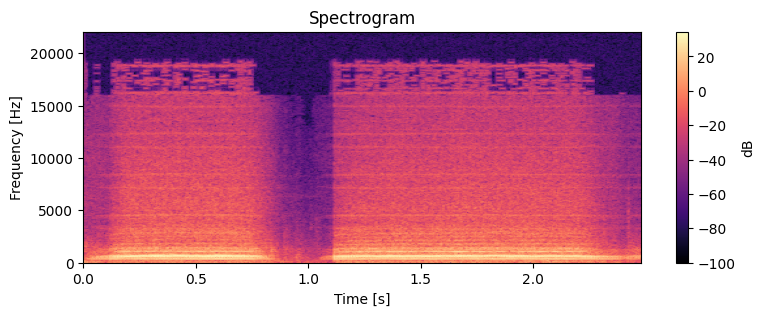

In [ ]:
#@title Linear spectrogram (STFT)
spec_fn = Spectrogram(n_fft=1024, hop_length=256, power=2)   # magnitude²
db_fn   = AmplitudeToDB(stype="power")

spec   = spec_fn(samples)
specDB = db_fn(spec)

plt.figure(figsize=(9,3))
plt.imshow(specDB, origin="lower", aspect="auto", cmap="magma",
           extent=[0, duration, 0, sr/2])
plt.colorbar(label="dB")
plt.ylabel("Frequency [Hz]"); plt.xlabel("Time [s]")
plt.title("Spectrogram")
plt.show()

# **🎹 5. Mel-spectrogram (perceptual frequency scale)**

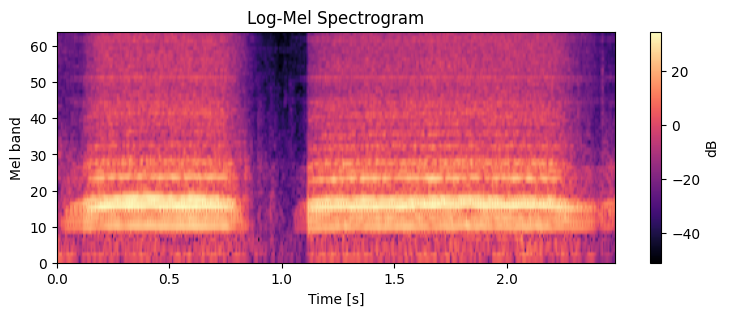

In [ ]:
#@title Mel spectrogram (log-mel)
mel_fn  = MelSpectrogram(sample_rate=sr, n_fft=1024,
                         hop_length=256, n_mels=64, f_max=8000)
mel_db  = db_fn(mel_fn(samples))

plt.figure(figsize=(9,3))
plt.imshow(mel_db, origin="lower", aspect="auto", cmap="magma",
           extent=[0, duration, 0, mel_fn.n_mels])
plt.colorbar(label="dB")
plt.ylabel("Mel band"); plt.xlabel("Time [s]")
plt.title("Log-Mel Spectrogram")
plt.show()